# 1. Setup and Imports


In [1]:
# ================================
# 1. IMPORTS
# ================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report,
                             RocCurveDisplay)
from sklearn.ensemble import RandomForestClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

# 2. Load Data


In [2]:
# ================================
# 2. LOAD AND COMBINE DATA
# ================================
train_path = 'UNSW_NB15_training-set.csv'
test_path = 'UNSW_NB15_testing-set.csv'

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

# Remove 'id' column (index, not predictive)
if 'id' in train_df.columns:
    train_df.drop('id', axis=1, inplace=True)
if 'id' in test_df.columns:
    test_df.drop('id', axis=1, inplace=True)

# Combine for consistent splitting
test_df['is_test'] = 1
train_df['is_test'] = 0
full_df = pd.concat([train_df, test_df], ignore_index=True)

# Separate features and target (binary)
X_full = full_df.drop(['label', 'attack_cat', 'is_test'], axis=1)
y_full = full_df['label']

# Stratified split: 80% train, 20% test (ensures same class distribution)
X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42, stratify=y_full
)

print(f"Train size: {X_train.shape}, Test size: {X_test.shape}")
print(f"Train class balance: {y_train.value_counts(normalize=True)}")
print(f"Test class balance: {y_test.value_counts(normalize=True)}")

Train size: (206138, 42), Test size: (51535, 42)
Train class balance: label
1    0.639077
0    0.360923
Name: proportion, dtype: float64
Test class balance: label
1    0.63908
0    0.36092
Name: proportion, dtype: float64


# 3. Exploratory Data Analysis (EDA)
**3.1 Basic info and missing values**

In [3]:
train_df.info()
print("\nMissing values:\n", train_df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 175341 entries, 0 to 175340
Data columns (total 45 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   dur                175341 non-null  float64
 1   proto              175341 non-null  str    
 2   service            175341 non-null  str    
 3   state              175341 non-null  str    
 4   spkts              175341 non-null  int64  
 5   dpkts              175341 non-null  int64  
 6   sbytes             175341 non-null  int64  
 7   dbytes             175341 non-null  int64  
 8   rate               175341 non-null  float64
 9   sttl               175341 non-null  int64  
 10  dttl               175341 non-null  int64  
 11  sload              175341 non-null  float64
 12  dload              175341 non-null  float64
 13  sloss              175341 non-null  int64  
 14  dloss              175341 non-null  int64  
 15  sinpkt             175341 non-null  float64
 16  dinpkt       

**3.2 Target variable distribution (label)**


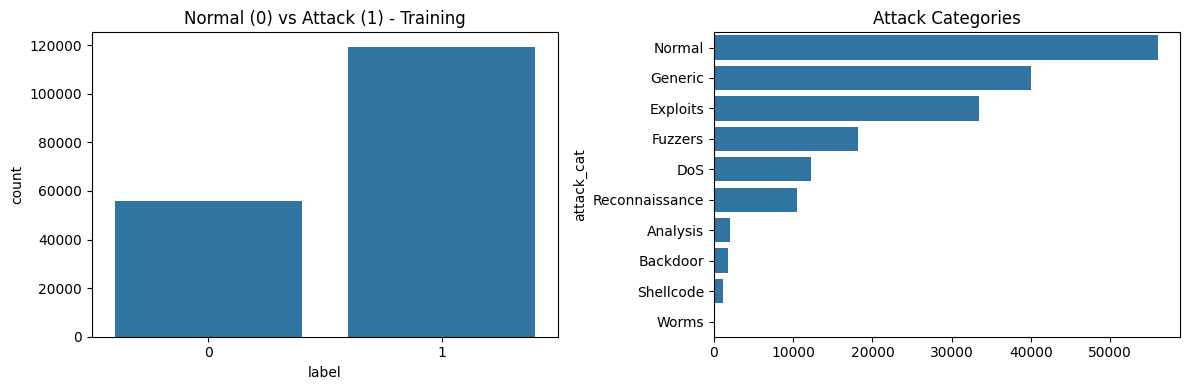

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.countplot(x='label', data=train_df, ax=axes[0])
axes[0].set_title('Normal (0) vs Attack (1) - Training')

attack_counts = train_df['attack_cat'].value_counts()
sns.barplot(y=attack_counts.index, x=attack_counts.values, ax=axes[1])
axes[1].set_title('Attack Categories')
plt.tight_layout()
plt.show()

**3.4 Numerical feature distributions (first 10 numerical columns)**

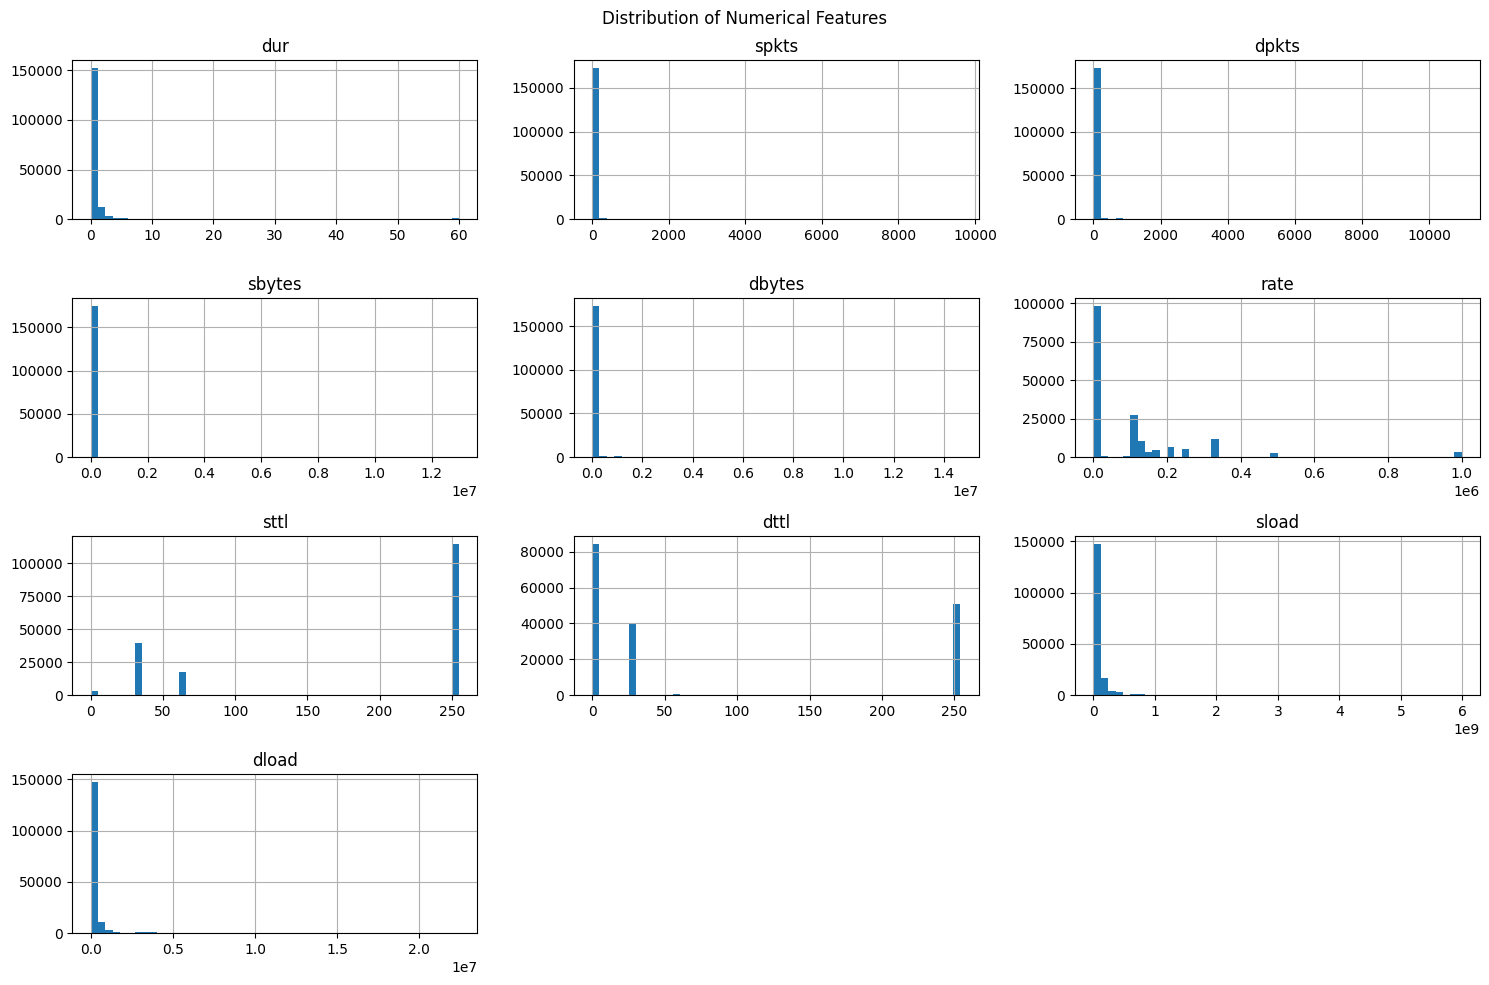

In [5]:
num_cols = train_df.select_dtypes(include=[np.number]).columns[:10]
train_df[num_cols].hist(bins=50, figsize=(15,10))
plt.suptitle('Distribution of Numerical Features')
plt.tight_layout()
plt.show()

**3.5 Correlation heatmap**

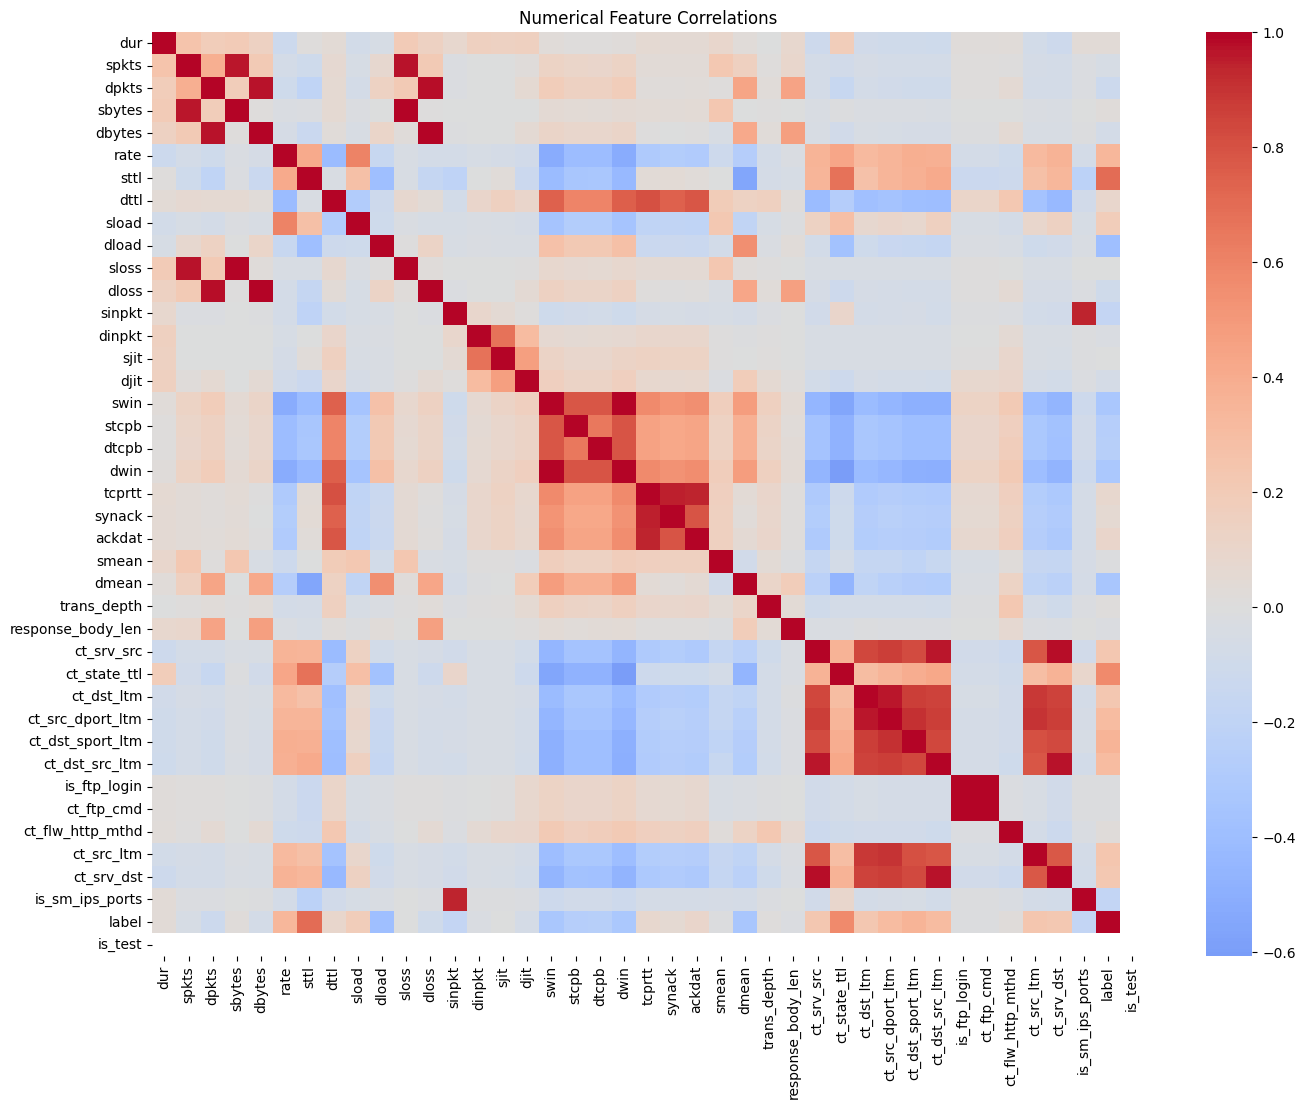

In [6]:
num_cols = train_df.select_dtypes(include=[np.number]).columns
plt.figure(figsize=(16,12))
sns.heatmap(train_df[num_cols].corr(), cmap='coolwarm', center=0)
plt.title('Numerical Feature Correlations')
plt.show()

# 4. Data Preprocessing

In [7]:
# ================================
# 3. PREPROCESSING PIPELINE (without data leakage)
# ================================
# Identify numeric and categorical columns
numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = ['proto', 'service', 'state']

# Replace inf with NaN
X_train[numeric_cols] = X_train[numeric_cols].replace([np.inf, -np.inf], np.nan)
X_test[numeric_cols] = X_test[numeric_cols].replace([np.inf, -np.inf], np.nan)

# Impute numeric: median
num_imputer = SimpleImputer(strategy='median')
X_train_num = pd.DataFrame(num_imputer.fit_transform(X_train[numeric_cols]), columns=numeric_cols)
X_test_num = pd.DataFrame(num_imputer.transform(X_test[numeric_cols]), columns=numeric_cols)

# Impute categorical: most frequent
cat_imputer = SimpleImputer(strategy='most_frequent')
X_train_cat = pd.DataFrame(cat_imputer.fit_transform(X_train[categorical_cols]), columns=categorical_cols)
X_test_cat = pd.DataFrame(cat_imputer.transform(X_test[categorical_cols]), columns=categorical_cols)

# One‑hot encode categorical columns
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_train_cat_encoded = encoder.fit_transform(X_train_cat)
X_test_cat_encoded = encoder.transform(X_test_cat)
cat_feature_names = encoder.get_feature_names_out(categorical_cols)

# Combine numeric and encoded categorical
X_train_processed = np.hstack([X_train_num.values, X_train_cat_encoded])
X_test_processed = np.hstack([X_test_num.values, X_test_cat_encoded])

# Scale numeric features only (re‑extract numeric part)
scaler = StandardScaler()
X_train_processed[:, :len(numeric_cols)] = scaler.fit_transform(X_train_processed[:, :len(numeric_cols)])
X_test_processed[:, :len(numeric_cols)] = scaler.transform(X_test_processed[:, :len(numeric_cols)])

print("Preprocessing complete.")

Preprocessing complete.


# 5. Model Training & Evaluation


In [8]:
# ================================
# 4. RANDOM FOREST WITH SMOTE AND HYPERPARAMETER TUNING
# ================================
# Create pipeline: SMOTE -> RandomForest
rf_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('rf', RandomForestClassifier(random_state=42, n_jobs=-1))
])

# Hyperparameter grid
param_grid = {
    'rf__n_estimators': [100],
    'rf__max_depth': [20],
    'rf__min_samples_split': [5],
    'rf__min_samples_leaf': [2]
}

# Use stratified k‑fold cross‑validation inside RandomizedSearchCV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
random_search = RandomizedSearchCV(
    rf_pipeline, param_grid, n_iter=10, cv=cv, scoring='f1',
    n_jobs=-1, random_state=42, verbose=1
)

# Fit on training data
random_search.fit(X_train_processed, y_train)

print(f"Best parameters: {random_search.best_params_}")
print(f"Best cross‑validation F1 score: {random_search.best_score_:.4f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters: {'rf__n_estimators': 200, 'rf__min_samples_split': 2, 'rf__min_samples_leaf': 1, 'rf__max_depth': None}
Best cross‑validation F1 score: 0.9595


In [9]:
# ================================
# 5. EVALUATION ON HELD‑OUT TEST SET
# ================================
best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test_processed)
y_proba = best_model.predict_proba(X_test_processed)[:,1]

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print("=== FINAL TEST SET RESULTS ===")
print(f"Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f} | AUC: {auc:.4f}")
print(classification_report(y_test, y_pred))

=== FINAL TEST SET RESULTS ===
Accuracy: 0.9517 | Precision: 0.9695 | Recall: 0.9545 | F1: 0.9620 | AUC: 0.9926
              precision    recall  f1-score   support

           0       0.92      0.95      0.93     18600
           1       0.97      0.95      0.96     32935

    accuracy                           0.95     51535
   macro avg       0.95      0.95      0.95     51535
weighted avg       0.95      0.95      0.95     51535



# 6. Visualizations for the Best Model (XGBoost Expected)
We will use XGBoost as the default choice because it typically yields the highest F1/AUC on UNSW‑NB15.

**6.1 Confusion Matrix Heatmap**

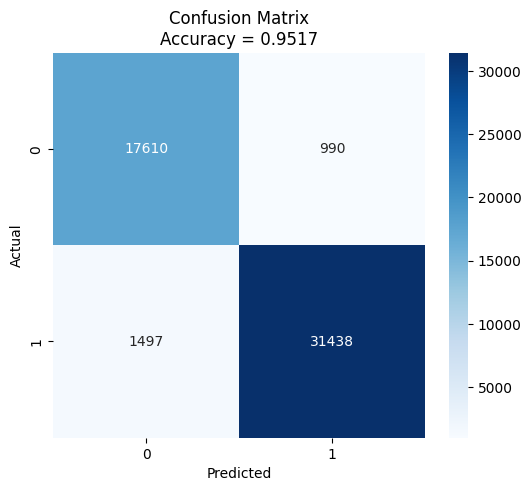

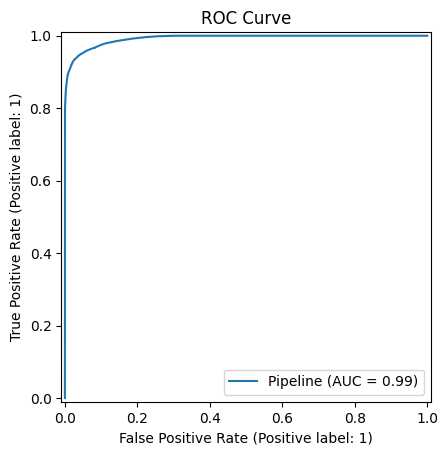

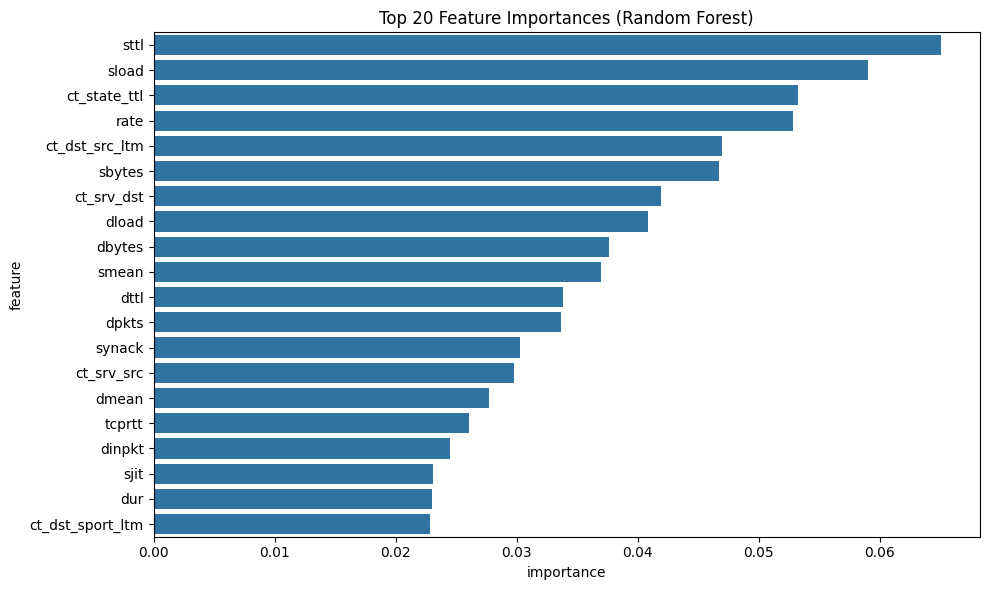

In [10]:
# ================================
# 6. VISUALISATIONS
# ================================
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f"Confusion Matrix\nAccuracy = {acc:.4f}")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ROC Curve
RocCurveDisplay.from_estimator(best_model, X_test_processed, y_test)
plt.title("ROC Curve")
plt.show()

# Feature Importance (from RandomForest)
rf = best_model.named_steps['rf']
feature_names = numeric_cols + cat_feature_names.tolist()
importances = rf.feature_importances_
imp_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
imp_df = imp_df.sort_values('importance', ascending=False).head(20)

plt.figure(figsize=(10,6))
sns.barplot(x='importance', y='feature', data=imp_df)
plt.title("Top 20 Feature Importances (Random Forest)")
plt.tight_layout()
plt.show()

# 7. Save the Best Model and Preprocessing Objects
We will save the XGBoost classifier, the scaler, and the label encoders for later deployment (e.g., on a Raspberry Pi 5).

In [11]:
# ================================
# 7. EXPORT FOR RASPBERRY PI 5
# ================================
import joblib

# Save the full pipeline (includes SMOTE, but note SMOTE is only for training)
# For inference, we only need the final RandomForest model and the preprocessors.
# However, to simplify, we can save the whole pipeline – but SMOTE will not be used during predict.
joblib.dump(best_model, 'dpi_rf_pipeline.pkl')

# Also save individual preprocessors for inference (optional)
joblib.dump(num_imputer, 'num_imputer.pkl')
joblib.dump(cat_imputer, 'cat_imputer.pkl')
joblib.dump(encoder, 'onehot_encoder.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(numeric_cols, 'numeric_cols.pkl')
joblib.dump(categorical_cols, 'categorical_cols.pkl')

print("All artifacts saved.")

All artifacts saved.


# 8. Inference Example (Raspberry Pi 5 ready)
Create a small function to preprocess a single raw flow and predict.

In [12]:
# ================================
# 8. INFERENCE FUNCTION (Raspberry Pi 5)
# ================================
def predict_flow(raw_dict):
    """
    raw_dict: dictionary with keys as original column names (except 'label', 'attack_cat', 'id')
    Returns: 0 = normal, 1 = attack
    """
    import pandas as pd
    import numpy as np
    import joblib
    
    # Load artifacts (do this once at startup)
    # For demo, we assume they are loaded
    
    df = pd.DataFrame([raw_dict])
    
    # Separate numeric and categorical
    df_num = df[numeric_cols].copy()
    df_cat = df[categorical_cols].copy()
    
    # Replace inf
    df_num = df_num.replace([np.inf, -np.inf], np.nan)
    
    # Impute
    df_num_imp = pd.DataFrame(num_imputer.transform(df_num), columns=numeric_cols)
    df_cat_imp = pd.DataFrame(cat_imputer.transform(df_cat), columns=categorical_cols)
    
    # One‑hot encode categorical
    df_cat_enc = encoder.transform(df_cat_imp)
    # Combine
    X = np.hstack([df_num_imp.values, df_cat_enc])
    # Scale numeric part
    X[:, :len(numeric_cols)] = scaler.transform(X[:, :len(numeric_cols)])
    
    return best_model.predict(X)[0]

# Example
sample = X_test.iloc[0].to_dict()  # convert first test row to dict
pred = predict_flow(sample)
print(f"Prediction: {'Attack' if pred==1 else 'Normal'}")

Prediction: Attack
